### Exploratory Data Analysis
#### Netflix Content Analysis
#### STEPS FOR EDA
##### 1.Data Cleaning and transformation
##### 2.Time-Series Analysis
##### 3.Text Data Manipulation
##### 4.Geographical & rating analysis
##### 5.Feature engineering class
##### 6.Advance Visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('darkgrid')

In [4]:
# Reading the dataset into csv
df = pd.read_csv(r"Datasets/Netflix_Titles Dataset/netflix_titles.csv")

In [7]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."


In [9]:
df.tail(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [10]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


#### Step 3: Data Cleaning & Transformation

In [12]:
# In this step we will handle missing values and correct data types by correcting data types means we have to convert the datatypes as per the columns names
# eg in given dataset we have date_added column which is in str, so we cannot extract month or year or date from it.So we have to convert that column into datetime object so we can extract month,date,year
# as per needed.
# This is important step.
# If we only drop very small percentage of rows containing null values,dropping them would be acceptable.
# Replace missing values with unknown or mode if that is categorical column. This way is usefull when you dont want to lose the other data present in that rows.

In [14]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [ ]:
# Handling missing values in 'director' column and 'cast' column

In [18]:
df['director'].isnull().sum()

np.int64(2389)

In [23]:
df['director'].fillna('Unknown',inplace=True)

In [27]:
df['cast'].isna().sum()

np.int64(718)

In [28]:
df['cast'].fillna('Unknown',inplace=True)

C:\Users\N!nad\AppData\Local\Temp\ipykernel_9684\2343259098.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('Unknown',inplace=True)


In [ ]:
# Handling missing values in 'country' column

In [36]:
df['country'].mode()[0]

'United States'

In [37]:
mode_country = df['country'].mode()[0]
df['country'].fillna(mode_country,inplace=True)

C:\Users\N!nad\AppData\Local\Temp\ipykernel_9684\3913538180.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(mode_country,inplace=True)


In [38]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           7
duration         0
listed_in        0
description      0
dtype: int64

In [ ]:
# Now two columns remained 'date_added' & 'rating'
# both columns have very less number of null values as per above so we can safely drop those rows
# or we can fill in those rows with mode as 'rating' is categorical column and 'date_added' is also categorical column unless its converted to proper datetime object using pd.todatetime

In [39]:
df.dropna(subset=['date_added','rating'],inplace=True)

In [41]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

##### Datatype conversion

In [46]:
df['date_added']= pd.to_datetime(df['date_added'],format='mixed',dayfirst=False)

In [48]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 789.1+ KB


In [ ]:
# Creating a new feature for year and month

In [52]:
df['year_added'] = df['date_added'].dt.year

In [53]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018


In [55]:
df['month_added'] = df['date_added'].dt.month

In [56]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12


#### EDA and Visualization based on Qestions

##### What is the porportaion of Movies vs TV Shows in Netflix

In [57]:
df['type'].value_counts()

type
Movie      5372
TV Show    2398
Name: count, dtype: int64

[]

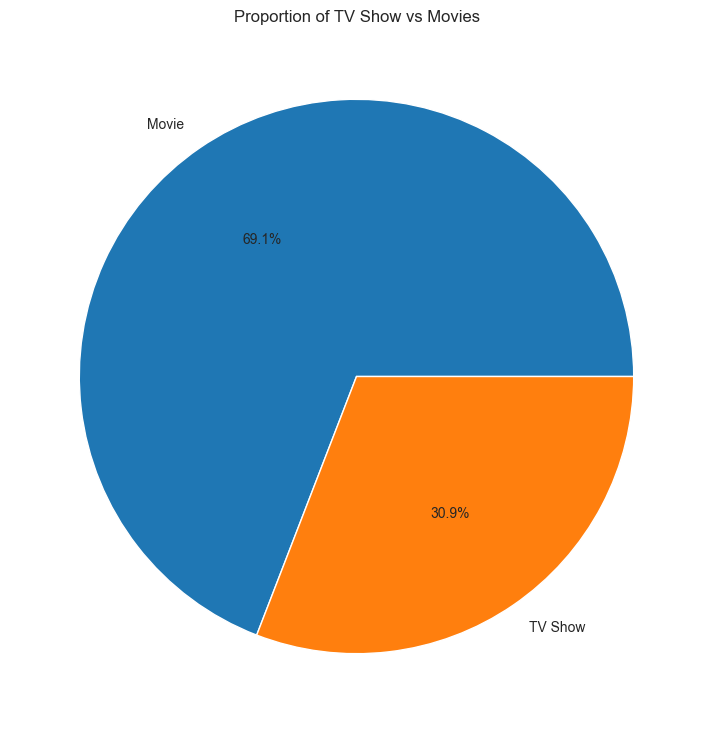

In [65]:
plt.figure(figsize=(10,9))
type_counts = df['type'].value_counts()
plt.pie(type_counts,labels=['Movie','TV Show'],autopct='%1.1f%%')
plt.title('Proportion of TV Show vs Movies')
plt.plot()

##### How content has been added over time

In [75]:
content_over_time = df.groupby(['year_added','type']).size().unstack().fillna(0)

<Figure size 1000x900 with 0 Axes>

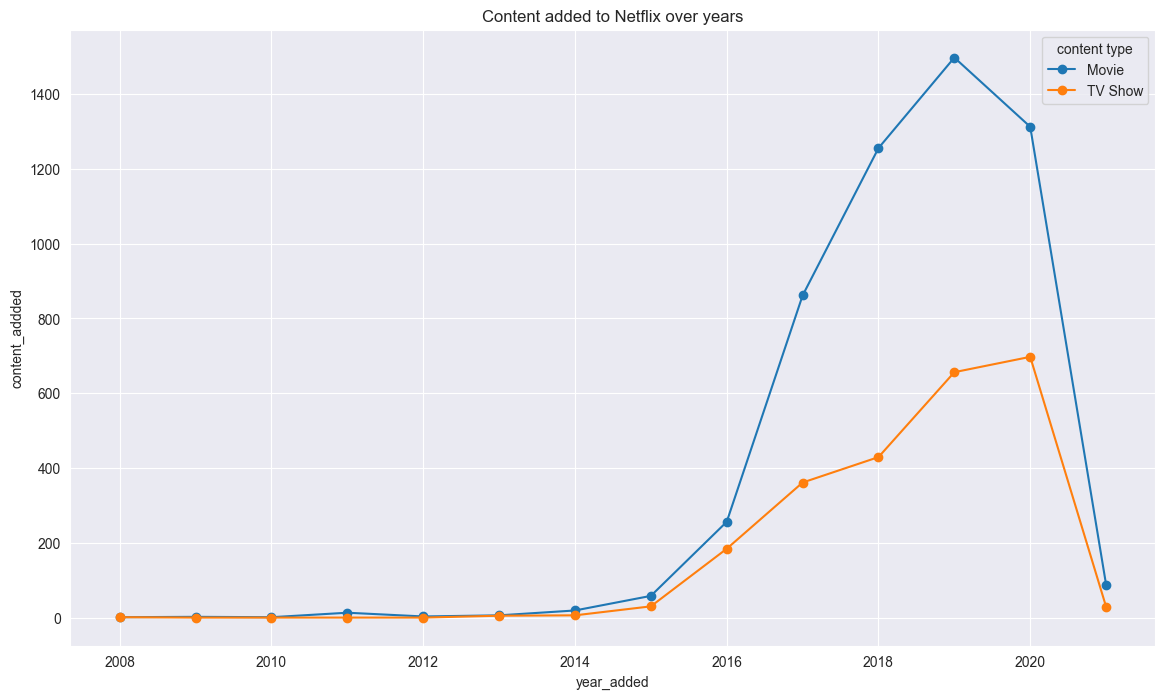

In [84]:
plt.figure(figsize=(10,9))
content_over_time.plot(kind='line',marker='o',figsize=(14,8))
plt.xlabel('year_added')
plt.ylabel('content_addded')
plt.title("Content added to Netflix over years")
plt.legend(title='content type')
plt.grid(True)
plt.show()

##### What is most popular Genres

In [89]:
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')  # NOTE:study this in detail when to use by why to use

In [100]:
top_genres_count = genres['genre'].value_counts().reset_index()
top_genres_count.columns = ['Genre','Count']

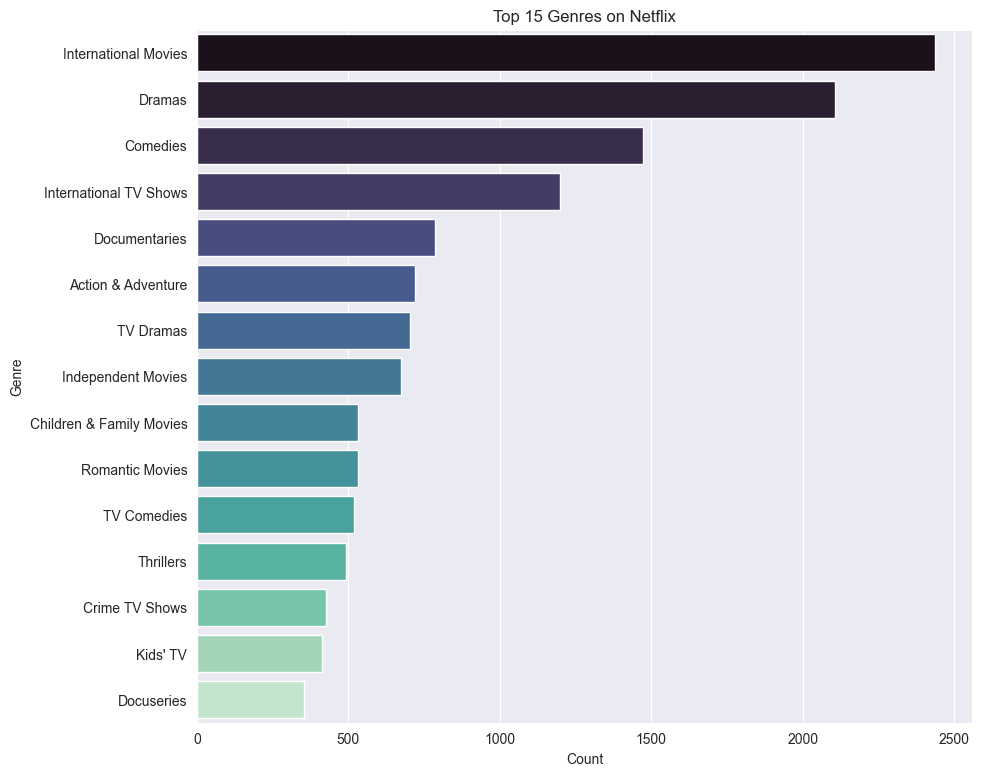

In [107]:
top_15_genres = top_genres_count.head(15)

plt.figure(figsize = (10,9))
sns.barplot(y='Genre',x='Count',data=top_15_genres,palette='mako',hue='Genre')
plt.title("Top 15 Genres on Netflix")
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

##### What is the distribution of content duration?

In [ ]:
# for this we have to create two different datasets because in duration both are there seasons and number of minutes.

In [109]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12


In [113]:
movies_df = df[df['type']=='Movie'].copy()

In [122]:
tv_show_df = df[df['type'] == 'TV Show'].copy()

In [125]:
tv_show_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,2017,7


In [126]:
movies_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12


In [130]:
movies_df['duration'] = movies_df['duration'].str.replace(' min','').astype(int)

In [135]:
tv_show_df['duration'] = tv_show_df['duration'].str.replace(' Seasons','').str.replace(' Season','').astype(int)

In [136]:
# Plot the distrubution

C:\Users\N!nad\AppData\Local\Temp\ipykernel_9684\3990553512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1],x='duration',data=tv_show_df,palette='rocket').set_title('TV Show Duration Distribution (Min)')


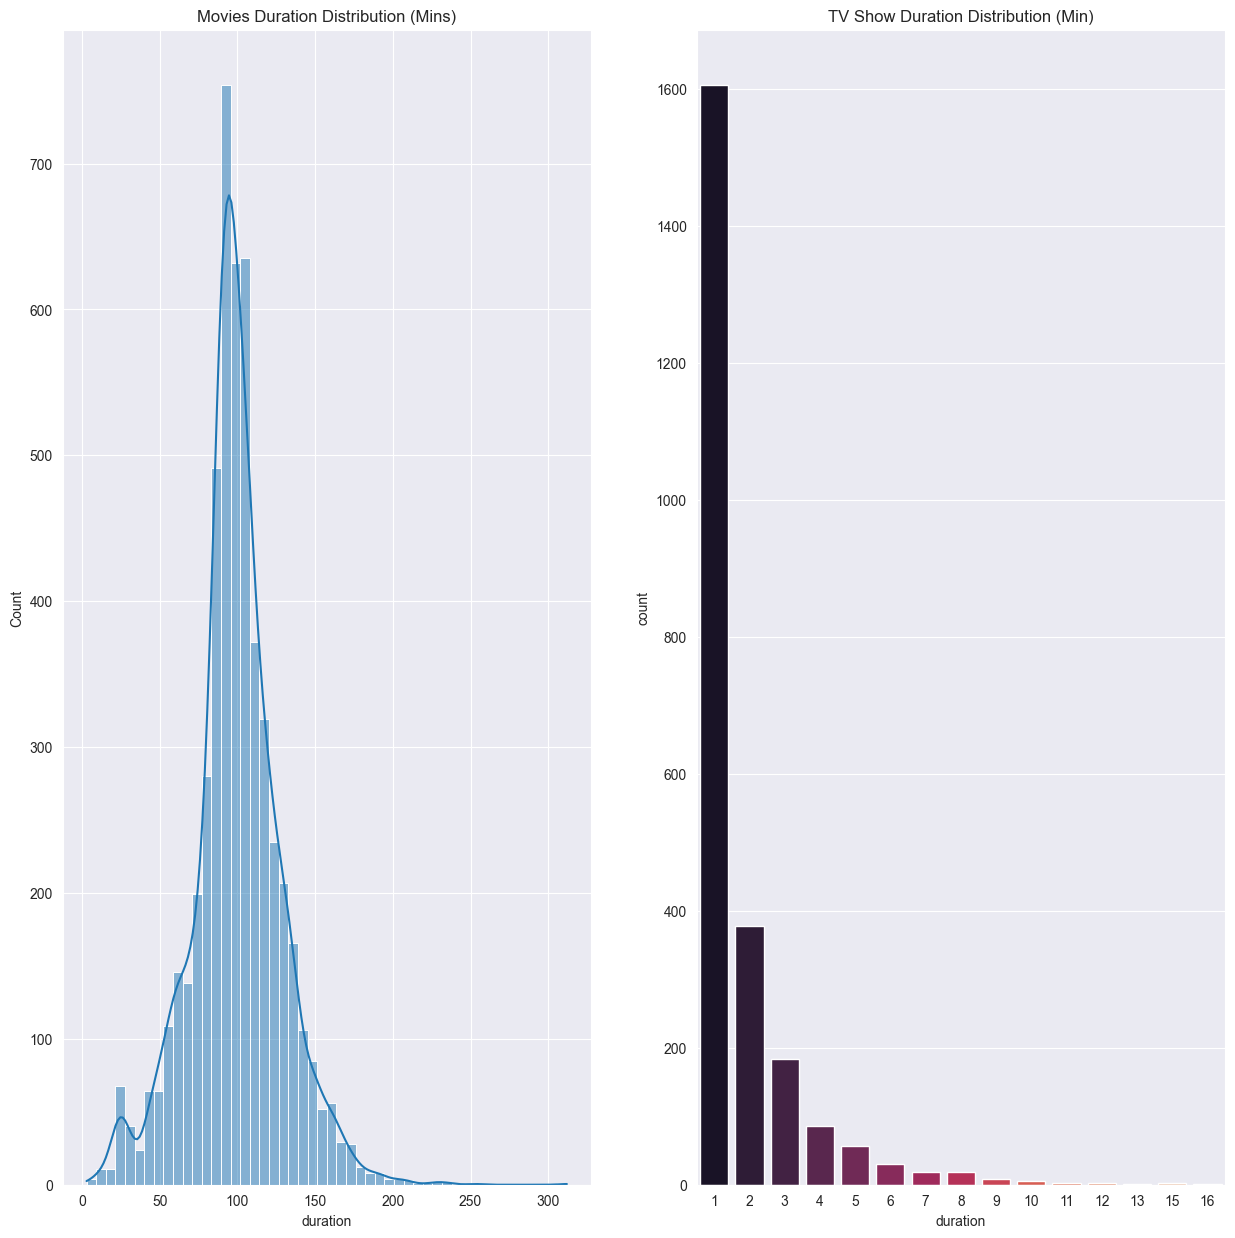

In [149]:
fig,axes = plt.subplots(1,2,figsize=(15,15))

sns.histplot(ax=axes[0],data=movies_df,x='duration',bins=50,kde=True).set_title('Movies Duration Distribution (Mins)')

sns.countplot(ax=axes[1],x='duration',data=tv_show_df,palette='rocket').set_title('TV Show Duration Distribution (Min)')

plt.show()

##### Where does the content come from? (Geographical Analysis)

In [155]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12


In [156]:
country = df['country'].str.split(', ')

In [168]:
countries = df.assign(country = df['country'].str.split(', ')).explode('country')

In [169]:
countries

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,Unknown,United Kingdom,2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,Unknown,Canada,2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3


In [170]:
top_15_countries = countries['country'].value_counts().reset_index()  # NOTE:go thorugh this line again try to understand how it works actually

In [171]:
top_15_countries

,country,count
0,United States,3792
1,India,990
2,United Kingdom,721
3,Canada,412
4,France,349
...,...,...
116,Panama,1
117,"United Kingdom,",1
118,Uganda,1
119,East Germany,1


In [172]:
top_15_countr = top_15_countries.head(15)

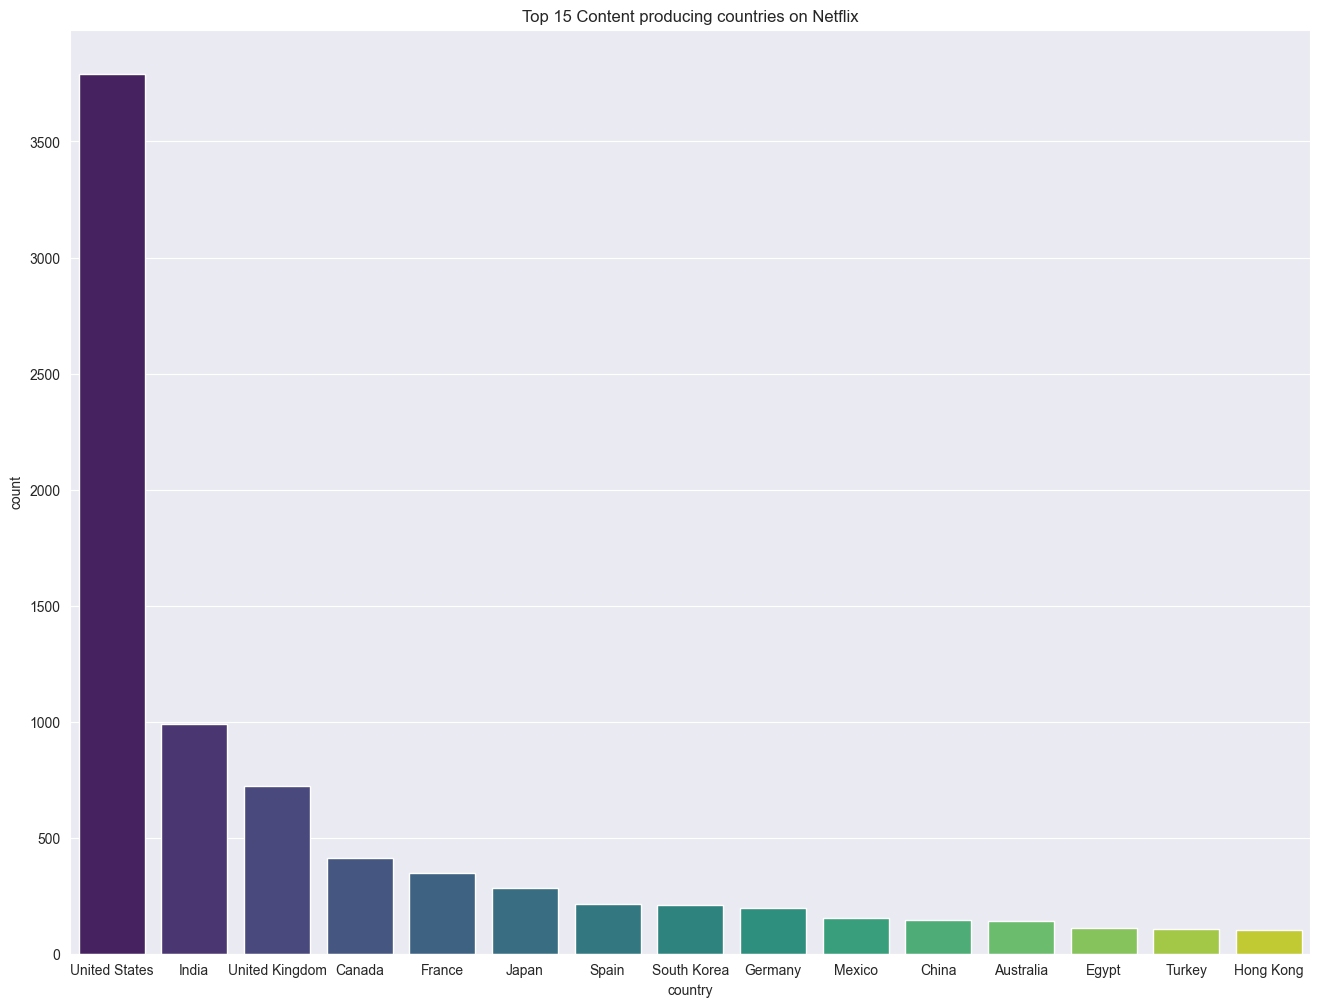

In [177]:
plt.figure(figsize=(16,12))
sns.barplot(y='count',x='country',data=top_15_countr,palette='viridis',hue='country')
plt.title('Top 15 Content producing countries on Netflix')
plt.show()

##### What is maturity ratings of content?

In [178]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12


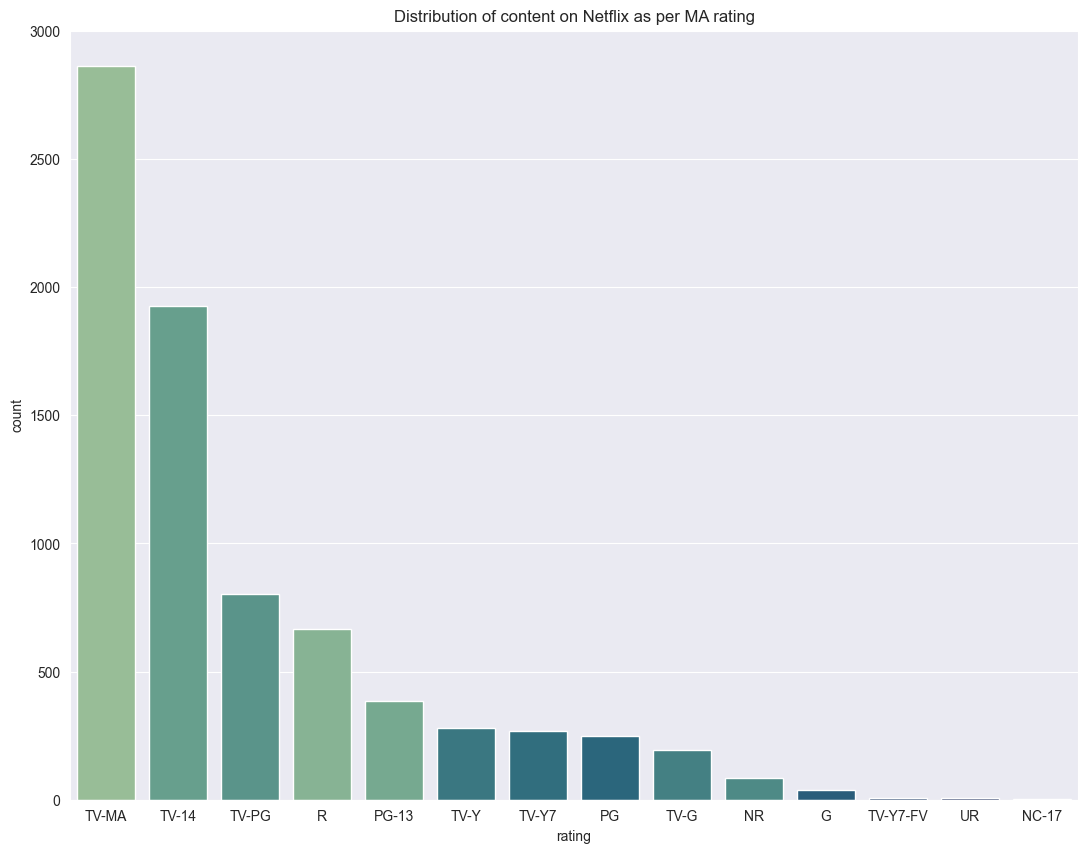

In [181]:
plt.figure(figsize=(13,10))
sns.countplot(x='rating',data=df,palette='crest',hue='rating',order=df['rating'].value_counts().index).set_title("Distribution of content on Netflix as per MA rating")
plt.show()

#### Feature engineering - Content Freshness

In [190]:
df['age_on_netflix'] = df['year_added'] - df['release_year']

In [200]:
content_age = df[df['age_on_netflix'] >=0]

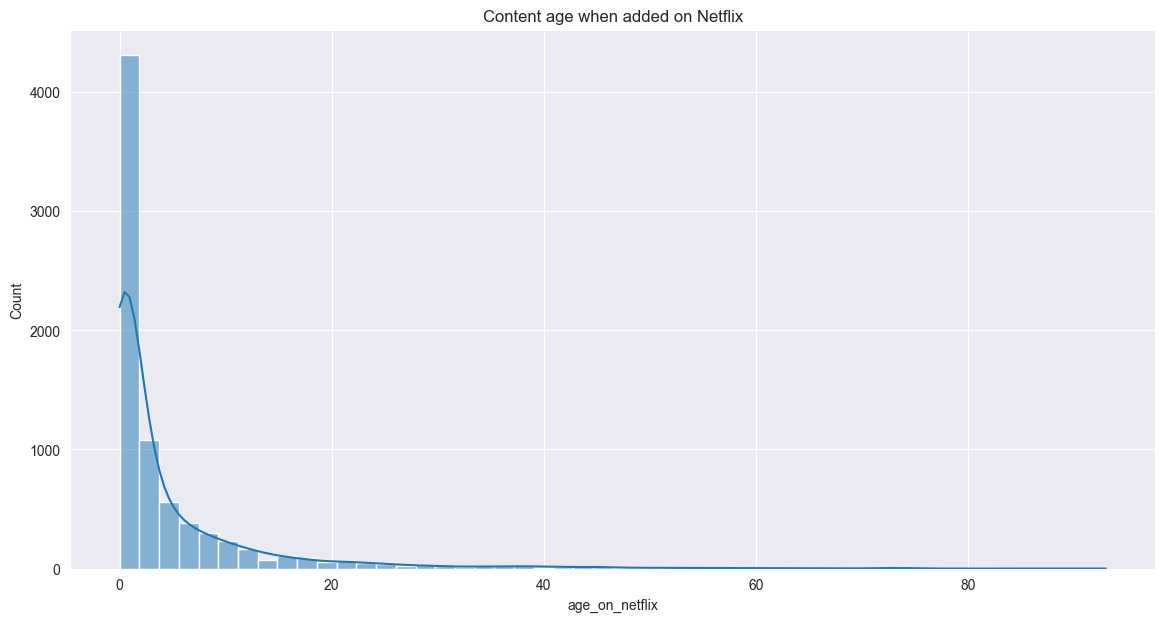

In [204]:
plt.figure(figsize=(14,7))
sns.histplot(data=content_age,x='age_on_netflix',bins=50,kde=True).set_title('Content age when added on Netflix')
plt.show()

##### Deeper Multivariate Analysis

In [233]:
top_genres = genres['genre'].value_counts().index[:5]  # why 5 b'coz we want to find top 5 genres content only
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()

In [236]:
genres_movies.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,International Movies


In [237]:
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min','').astype(int)

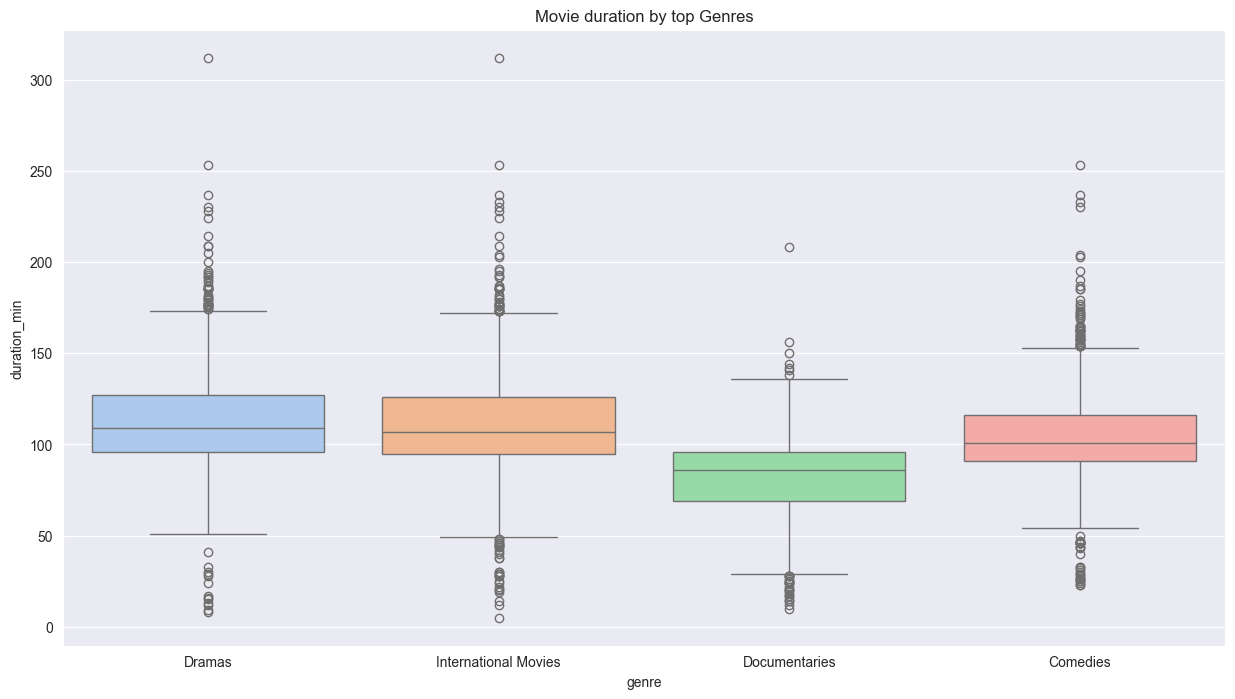

In [245]:
plt.figure(figsize=(15,8))
sns.boxplot(data=genres_movies,x='genre',y='duration_min',palette='pastel',hue='genre')
plt.title("Movie duration by top Genres")
plt.show()

#### Word Cloud -- using 'description' column to see what themes are common in Netflix content

In [246]:
df['description']

0       In a future where the elite inhabit an island ...
1       After a devastating earthquake hits Mexico Cit...
2       When an army recruit is found dead, his fellow...
3       In a postapocalyptic world, rag-doll robots hi...
4       A brilliant group of students become card-coun...
                              ...                        
7782    When Lebanon's Civil War deprives Zozo of his ...
7783    A scrappy but poor boy worms his way into a ty...
7784    In this documentary, South African rapper Nast...
7785    Dessert wizard Adriano Zumbo looks for the nex...
7786    This documentary delves into the mystique behi...
Name: description, Length: 7770, dtype: object

In [248]:
text = ' '.join(df['description'])

In [249]:
wordcloud = WordCloud(width=800,height=400,background_color='black').generate(text)

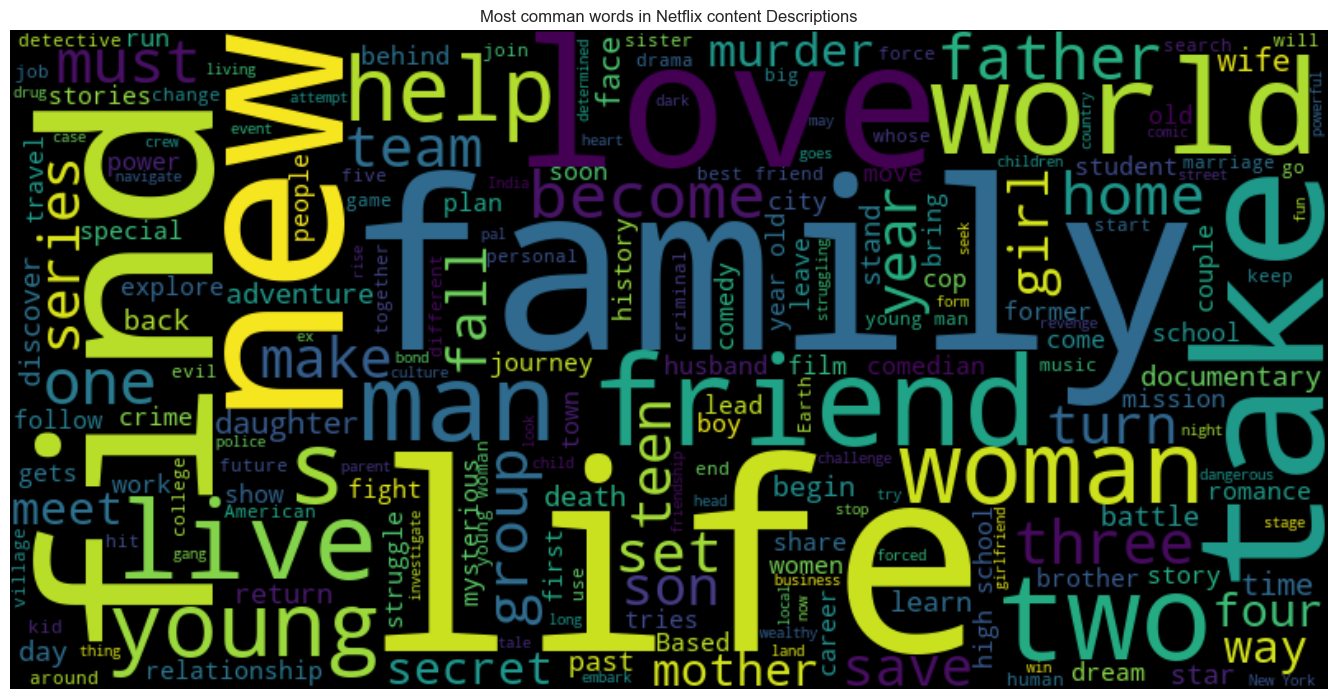

In [253]:
plt.figure(figsize=(17,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Most comman words in Netflix content Descriptions')
plt.show()

##### Assignment to solve
###### How has the distribution of content rating changed over time
###### is there a relationship between content age and content type ( Movie vs TV show)
###### can we identify any trends in content production based on the release year vs year added to netflix
###### what are the most common phrases or words in content descriptions
###### who are the top directors on netflix

